For easy reading, refer to Colab:  [Cloudette_setup](https://colab.research.google.com/drive/1V2y7UZm9n61LqkFyXudDFQSYSzaV7hsy?usp=sharing) ✈️

# Cloudette
In this notebook, the development, validation, and evaluation of **Cloudette** are showcased. It's an AI chatbot for assisting Cabin Crew Training with a Training Manual PDF as dataset. The notebook includes a step-by-step process explaining both codes and the results. This is to get education more effective and accessible to anyone into flight attendant training and PROGRAMMERS (Specifically, Rag-based LLM). But really, it's just for school. Hence, this disclaimer:

*I'm not an expert. Yes, I made a chatbot make me a chatbot. YES, I'M WORTHLESS! **Nothing is ever the future, only the reality!!!** Still, I'm doing this cuz I'm a nerd, I wanna learn and help another worthless nerd coz my school SUCKS!*




> TLDR: The chatbot works. You'll learn how with my explanations, TLDRs, and/or In-code comments. Do anything you want with this. Credit me.






## 1. Dependency Installation

Dependency means external libraries or tools! This part prepares and configures the runtime environment before executing the RAG pipeline.  Almost all here are Python, the rest are system-level tools. `pypdf` for PDF text extraction. `pytesseract`, `poppler`, `tesseract-ocr` for OCR processing (texts inside images). `pdf2image` for converting PDF pages to images for OCR. `sentence-transformers` for text embedding generation. `FAISS` for vector indexing. `transformers`, `accelerate` for LLM loading and running. `ipywidgets` for interactive interface deployment. `camelot-py` - installs Camelot with PDF parsing support. `ghostscript` - required for Camelot to read PDF streams.

> TLDR: Without this part, system can't read the texts, run LLM, and let you even talk to the chatbot. AKA, best time to not even begin this and just appreciate the trees.






In [1]:
#Python libraries
!pip -q install pypdf sentence-transformers faiss-cpu transformers accelerate ipywidgets pytesseract pdf2image camelot-py
#System-level tools
!apt-get install -q poppler-utils tesseract-ocr ghostscript

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.2/313.2 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 36.3 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following additional packages will be installed:
  fonts-droid-fallback fonts-noto-mono fonts-urw-base35 libgs9 libgs9-common
  libidn12 libijs-0.35 libjbig2dec0 poppler-data
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf fonts-texgyre
  ghostscript-x fonts-japanese-mincho | 

## 2. Uploading the Dataset

Chabots need dataset/s to know what to generate to the user. You can upload here from your File Explorer. It requires PDF format since we installed a PDF text extraction earlier. What I used was: `"Airline Cabin Crew Training Manual" by Emmy Arsonval Maniriho`, which can be seen in my github or scribd(Fck that). My professor accepted this dataset based on: **manual/handbook, PDF file, essential/paper-worthy**. But you don't have to follow. You can use any dataset here too, even multiple but obviously the evaluation part is about my dataset.

> TLDR: Without this part, system can't take PDF and won't know about cabin crew training. Or a school handbook. Or a job manual. Or a scandal documented in a PDF... Who's the real victim, Chatgpt?

In [2]:
from google.colab import files
uploaded = files.upload()
pdf = list(uploaded.keys()) #Stores pdf

Saving 710958313-Airline-Cabin-Crew-Training-Manual.pdf to 710958313-Airline-Cabin-Crew-Training-Manual.pdf


## 3. Data Preprocessing

**Preprocessing** is the preparation of raw dataset for AI processing. For a chatbot-purpose dataset, this can be done through extraction, normalization, chunking . The system extracts text from PDFs using ***PdfReader***, from images using ***OCR (Optical Character Recognition)***, and from tables using ***Camelot***, converting tables into text. Extracted text is then cleaned by ***normalizing whitespace*** (removing extra spaces, tabs, and newlines). ***Chunking*** then splits the extracted content into smaller, overlapping segments (overlapping to ensure no important context is lost between chunks), so models can handle long documents efficiently. Finally, each chunk is ***normalized for embedding generation*** by lowercasing and replacing dashes with spaces.

> TLDR: Raw data can be messy (In LLM, spaces, weird charcters, images, tables...) so there needs to be PREPROCESSING. This can mean cleaning, splitting, and normalizing the text so model gives more accurate answers.


In [3]:
from pypdf import PdfReader  #For PDF text
from pdf2image import convert_from_path  #Converting PDF page to image
import pytesseract, re  #For PDF image
import camelot  #For PDF table
import warnings
import logging

#Suppress Camelot/UserWarnings about image-based pages or missing tables to avoid spam output
warnings.filterwarnings("ignore", category=UserWarning)
#Suppress pdfminer font warnings
logging.getLogger("pdfminer").setLevel(logging.ERROR)



#size=1200 keeps each chunk long enough to include full paragraphs, lists, or tables
#overlap=200 makes sure nothing important is cut off between chunks
#Both for huge chunk
def get_chunks(path, size=1200, overlap=200):
    """Extract all text from PDF/s (including OCR and tables) and split into overlapping chunks"""
    text = ""
    reader = PdfReader(path)


    for i, page in enumerate(reader.pages):
        page_text = page.extract_text() or ""
        if page_text.strip():  #Extract text
            text += page_text + " "
        else:  #OCR for image-only pages
            images = convert_from_path(path, first_page=i+1, last_page=i+1)
            for img in images:
                text += pytesseract.image_to_string(img) + " "
    #Extract tables
    tables = camelot.read_pdf(path, pages='all')
    for table in tables:
        df = table.df
        for _, row in df.iterrows():
            text += " | ".join(row) + " " #Convert row to text


    #Clean up whitespace (spaces, tabs, newlines)
    text = re.sub(r"\s+", " ", text)


    #Splits text into overlapping chunks
    chunks = []
    for i in range(0, len(text), size - overlap):
        chunks.append({"source": path, "text": text[i:i+size]})

    return chunks


#Extract chunks from all uploaded PDFs
chunks = [c for p in pdf for c in get_chunks(p)]
print("Total chunks:", len(chunks))

#Normalize text for embeddings (lowercasing, replacing dashes with space)
for c in chunks:
    c["text_clean"] = re.sub(r"[-–—]", " ", c["text"].lower())

Total chunks: 380


## 4. Embedding and Vector Indexing

We have chunks. Now we convert it into ***embeddings***, numerical vectors that represent their meaning in high-dimensional space using a sentence transformer model `all-MiniLM-L6-v2` (fast, memory-efficient, ideal for RAG). These embeddings get stored in a FAISS vector index that allows system to quickly find the chunks most relevant to a **user query** based on *semantic similarity* (related meaning of words).

> TLDR: Computer math stuff now. Chunks (text) become vectors (number) so related words (ex. dog and bowl) can be found and help the chatbot give better answers.

In [4]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

#Load embedding model
embedder = SentenceTransformer("sentence-transformers/all-mpnet-base-v2") #more accurate
texts = [c["text_clean"] for c in chunks]

#Computing embeddings
emb = embedder.encode(
    texts,
    batch_size=32, #Process 32 chunks per batch
    show_progress_bar=True,
    convert_to_numpy=True, #Return embeddings as vectors in a NumPy array
    normalize_embeddings=True #Adjusts vectors for proper similarity comparisons
)

# FAISS index for fast similarity search
dim = emb.shape[1]
index = faiss.IndexFlatIP(dim) #Set up the similarity search
index.add(emb) #Add all chunk vectors to the index

#Should be same number with total chunks
print("Total vectors in index:", index.ntotal)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

Total vectors in index: 380


## 5. Deciding on CHABOT MODEL w/ preloading and metrics
Now, any **LLM(Large Language Model) model** could do since it generates and understands complex texts. Comparison is just for well, the research paper and so you won't have to bear with an annoying chatbot. It's based on generation time, token count (how big response it is), and similarity to real text from the manual. You can decide there. Before that, in choosing the models *at all* you need to consider **GPU, your dataset(like can it interpret drawings?) and if you want it open-source(or get API key or paying idk I ain't doing that).

You can choose fine-tuned or RAG-based... **RAG(Retrieval-Augmented Generation)-based LLM** is just preferred because it doesn’t require a large labeled dataset and can retrieve relevant context in real time, making the chatbot's answers more accurate. It's our main task actually to choose a model and since I want fast running and open-source for Google Colab, I chose the ones below. You can see it's like 1-3 Billion parameters, and that's because when I tried 7B, it's too long LOL!

Preloading is to see the models' correct comparison results that shows their actual speed and efficiency, not their condition before downloading or initializing it.

**Evaluation metrics to use for RAG:**
- Retriever-level: Recall@K, Precision@K, Context Relevancy
- Generation-level: Faithfulness, Answer Relevancy, Groundedness

> TLDR: RAG-Based LLM models are suited for chatbots because it's adaptive rather than narrow-minded. Comparing RAG models have specific metrics like when you want to diet so you compare food with the metrics of calories, not taste. But to compare models, you need to preload them first to get accurate results.

##Answers to sample questions(scroll down)
RAGAS evaluation tool and more are good for dataset with lots of list I think, but you need to pay... For now, we are limited to just copy pasting sentence/paragraph formatted answers (for good results).

In [5]:
import unicodedata

def normalize(text):
    return unicodedata.normalize("NFKD", text).replace("\n", " ").replace("\xa0", " ").strip()

#Manually copy paste from pdf. Do not reword or skip sentences. DO NOT USE LISTS.
reference_answers = [
    #FACTUAL/DEFINITION ANSWERS
    "Greenwich Mean Time is international time, the basis of the world time clock. It defines date and time and the exact time.",
    "It is meant to provide the right of entry into another country purely for the purpose of making travel connections onward to a third country. Regulations related to transit vary from country to country and should be checked.",
    "This is the baggage which cannot be transported on the conveyor belt because it is fragile, heavy and bulky or in need of special treatment such as live animals, sporting equipment, musical equipment, baby strollers,courrier baggage,etc.",
    "Table d'hôte is a French phrase which literally means \"host's table\". It is used to indicate a fixed menu where multi-course meals with limited choices are charged at a fixed price.",
    "Make-up is concerned with sorting and preparing baggage for loading onto the aircraft. The main points to be taken into account when dealing with baggage make –up are: Sorting by flight, Separation by class of travel.",
    "A kit for the use of cabin crew members in managing incidents of ill health associated with a case of suspected communicable disease, or in the case of illness involving contact with body fluids.",
    "Marking and Labeling is the process through which information about the Dangerous Goods present in the package are communicated to carriers, consignees, and the public.",
    "The crew member should undergo the training focusing on Flight Preparations, Pre-flight Crew Briefing, Pre-flight Preparation, Boarding Process, Pre Take-Off Preparations, Passenger Safety Briefing, Preparing for Take-off and Preparing for Landing training.",
    "The authoritarian leader takes all decisions by himself/herself and will try to implement them even resorting to the use of force or coercion.",

    #SITUATIONAL/PROCEDURAL ANSWERS
    "Sprain is an injury which occurs as a result of stretching or tearing of ligaments. Strain is an injury which occurs as a result of stretching or tearing of muscles",
    "If bone is protruding, cover with clean cloth once bleeding is controlled",
    "Boarding responsibilities for cabin crew include: checking validity of passenger boarding cards, assisting passengers with seat assignments, monitoring cabin baggage, electronic devices, ensuring exit seat criteria are met, monitoring child restraint devices as well as keeping a visual watch of the cabin at all times. Cabin crew should be evenly distributed throughout the cabin in order to monitor the boarding process.",
    "After cabin crew log their arrival time at the operations ofice, they ill in necessary documentation such as customs, immigration, and log timing sheets.",
    "Pre-flight aircraft checks must be accomplished on each flight prior to passenger boarding.",

    #POLICY ANSWERS
    "Minimum jewellery should be worn by the service staff. A wrist watch, finger ring and plain earrings (for girls only) should be permitted.",
    "Airline does not allow duplicate bookings. In addition, the creation of bookings across one or more PNRs and/or GDSs, where it is logically impossible to travel, is not permitted.",

    #UNRELATED/NOISE
    None,  # 707 will hack Cloudette
]

norm_chunks  = [normalize(c["text"]) for c in chunks]
norm_answers = [normalize(a) if a else None for a in reference_answers]

relevant_indices = []
for answer in norm_answers:
    if answer is None:
        relevant_indices.append(None)
        continue
    found = [i for i, c in enumerate(norm_chunks) if answer in c]
    #Take the first match only (or None if not found) for one ground-truth index.
    relevant_indices.append(found[0] if found else None)

print("Relevant indices:")
print(relevant_indices)

Relevant indices:
[101, 119, 160, 280, 161, 255, 266, 142, 325, 259, 259, 167, 152, 164, 340, 220, None]


##Loading one model

In [6]:
#Transformers - loading and using pre-trained LLMs
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from sentence_transformers import util #for util
import torch #PyTorch, the framework for running the model.
import time #how fast the model does its task
import matplotlib.pyplot as plt #GRAPHS for generation time, token count, and similarity
import nltk #for groundness metric



#Candidate models. UNCOMMENT FOR ONLY ONE MODEL (Colab Free can't do multiple big ones!!! Kyahh!)
models = [
    #"Qwen/Qwen2.5-3B-Instruct",
    "Qwen/Qwen2.5-7B-Instruct",
    #"mistralai/Mistral-7B-Instruct-v0.1",
    #"tiiuae/falcon-7b-instruct",


]

SYSTEM_PROMPT = (
    "You are Cloudette, a cabin crew assistant. "
    "You MUST answer ONLY using the exact information in the provided context. "
    "NEVER use your own knowledge. If the answer is explicitly stated in the context, quote it directly. "
    "If it is not in the context, say you don't know. "
    "Keep your answer concise, around 2-4 sentences or equivalent."
)

preloaded_models = {}
for model_name in models:
    try:
        print(f"Loading {model_name}...")
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            device_map="auto",
            torch_dtype=torch.float16,
        )

        gen_pipeline = pipeline(
            "text-generation",
            model=model,
            tokenizer=tokenizer,
            do_sample=False,
            max_new_tokens=120, #120 gives room for 2-3 full sentences.
        )
        preloaded_models[model_name] = (gen_pipeline, tokenizer)
        print(f"  ✓ Loaded {model_name}")
    except Exception as e:
        print(f"  ✗ Skipping {model_name}: {e}")

Loading Qwen/Qwen2.5-7B-Instruct...


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


  ✓ Loaded Qwen/Qwen2.5-7B-Instruct


##Formula for metrics
Again, not RAGAS. This is manual.

In [7]:
import matplotlib.pyplot as plt #GRAPHS for generation time, token count, and similarity

def cosine_sim(a, b):
    """Return scalar cosine similarity between two text strings."""
    ea = embedder.encode([a], convert_to_numpy=True, normalize_embeddings=True)
    eb = embedder.encode([b], convert_to_numpy=True, normalize_embeddings=True)
    return float(np.dot(ea, eb.T)[0, 0])   #[0,0] extracts scalar from 2D array

def recall_at_k(all_indices, relevant_indices, k):
    """Did the retriever find the ground-truth chunk in its top-k results?"""
    correct = sum(1 for retrieved, relevant in zip(all_indices, relevant_indices)
                  if relevant is not None and relevant in retrieved[:k])
    total = sum(1 for r in relevant_indices if r is not None)
    return correct / total if total > 0 else 0

def precision_at_k(all_indices, relevant_indices, k):
    """Of the k retrieved chunks, how many were the correct one?"""
    correct = sum(1 for retrieved, relevant in zip(all_indices, relevant_indices)
                  if relevant is not None and relevant in retrieved[:k])
    #Only count queries that HAVE a ground truth answer, not NONE or else, low precision
    total_queries_with_gt = sum(1 for r in relevant_indices if r is not None)
    return correct / total_queries_with_gt if total_queries_with_gt > 0 else 0

def context_relevancy(question, context):
    return cosine_sim(question, context)

def faithfulness(answer, context):
    return cosine_sim(answer, context)

def answer_relevancy(answer, reference):
    if reference is None:
        return None
    return cosine_sim(answer, reference)

def groundedness(answer, context):
    return faithfulness(answer, context)

##Sample questions

In [8]:
#Invent your questions!!!
sample_user_prompts = [
    #FACTUAL/DEFINITION QUESTIONS
    "What is GMT?",
    "what is a transit visa",
    "whats excceptional baggage ????",
    "whats table d'hôte?",
    "whats make-up?",
    "what is a universal precaution kit?",
    "what is marking and labeling",
    "what do cabin crew training focus on??",
    "authoritatian leadership style",

    #SITUATIONAL/PROCEDURAL QUESTIONS
    "difference of sprain and strain??",
    "what to do if a bone is protruding",
    "What are the boarding responsibilities of cabin crew?",
    "What forms do cabin crew fill after logging arrival time?",
    "when should preflight aircraft checks be accomplished",

    #POLICY QUESTIONS
    "are jewelry allowed for flight attendants??",
    "do airlines allow duplicate bookings????",

    #UNRELATED/NOISE
    "707 will hack Cloudette.",
]

##Evaluation (w/ plot metrics)
Graphs! Pictures! Everyone's favorite.

Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Testing: Qwen/Qwen2.5-7B-Instruct


Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Q1 debug ---
  Top similarity score : 0.694
  Top chunk preview    : t connects the north and south poles. The time at Greenwich and all other countries in this zone is called Greenwich Mean Time (GMT) and is also referred to as Universal Time Coordinated (UTC). What is Greenwich Mean Time (GMT)? Greenwich Mean Time or Meridian Time has been a time standard since 188
--------------------


Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...


--- Q15 debug ---
  Top similarity score : 0.510
  Top chunk preview    : ore relying on it to support a point in a presentation. KISS Keep It Simple Short!: The presentation should not be too much wordy. There should be one slide per minute and Not too much text. STRUCTURING A clear structure to the presentation will not only provide a presenter with a clear path to foll
--------------------


Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Q16 debug ---
  Top similarity score : 0.570
  Top chunk preview    : ph 3.2 of IATA resolution 824, Airline can provide travel agencies with booking policy and travel agencies are obliged to comply with it. Airline ticketing policy has taken into consideration and complies with IATA resolutions; the obligations of the travel agency are described in IATA Resolutions 8
--------------------


Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Q17 debug ---
  Top similarity score : 0.183
  Top chunk preview    : l were signiﬁcant problems to overcome. In 1952, a 36-seat British-made jet, the Comet, ﬂew from London to Johannesburg, South Africa, at speeds as high as 500 miles per hour. Two years later, the Comet’s career ended abruptly following two back-to-back accidents in which the fuselage burst apart du
--------------------

Metrics for Qwen/Qwen2.5-7B-Instruct:
  Avg Gen Time (s): 32.173
  Recall@K: 0.75
  Precision@K: 0.75
  Context Relevancy: 0.53
  Faithfulness: 0.633
  Answer Relevancy: 0.874
  Groundedness: 0.633


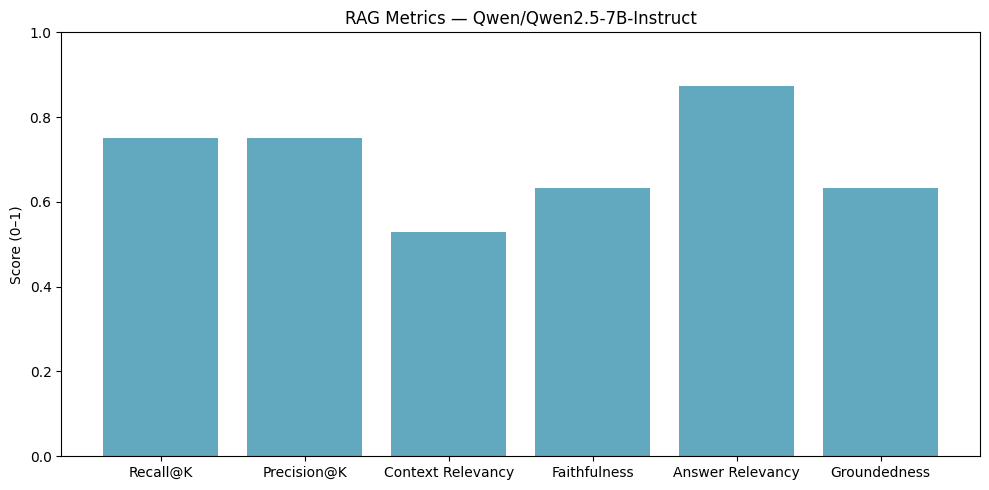


Generated Answers:

Q1: What is GMT?
  Answer:    Greenwich Mean Time (GMT) and Universal Time Coordinated (UTC) are time standards based on the Prime Meridian running through Greenwich, England. The time at Greenwich and all other countries in this zone is GMT/UTC, serving as the basis for the world time clock and defining dates and times internationally.
  Reference: Greenwich Mean Time is international time, the basis of the world time clock. It defines date and time and the exact time.
  Ans Rel:   0.838
----------------------------------------------------------------------

Q2: what is a transit visa
  Answer:    A transit visa is meant to provide the right of entry into another country purely for the purpose of making travel connections onward to a third country. Regulations related to transit vary from country to country and should be checked.
  Reference: It is meant to provide the right of entry into another country purely for the purpose of making travel connections onward t

In [9]:
SIMILARITY_THRESHOLD = 0.3 #0.3 catches more true positives. Higher may reject them.

k = 3

for model_name, (gen_pipeline, tokenizer) in preloaded_models.items():
    print(f"\n{'='*60}")
    print(f"Testing: {model_name}")
    print('='*60)

    _ = gen_pipeline("Warmup.") #GPU warm-up

    results = {
        "per_query_time": [],
        "context_relevancy": [],
        "faithfulness": [],
        "answer_relevancy": [],
        "groundedness": [],
        "answers": [],
    }
    all_retrieved_indices = []

    for i, q in enumerate(sample_user_prompts):
        #Retrieve
        q_emb = embedder.encode([q], convert_to_numpy=True, normalize_embeddings=True)
        D, I = index.search(q_emb, k)
        all_retrieved_indices.append(I[0].tolist())

        if D[0][0] < SIMILARITY_THRESHOLD:
            context = "No relevant information found in the training manual."
        else:
            context = "\n\n".join([chunks[j]["text"] for j in I[0][:k]])
        print(f"\n--- Q{i+1} debug ---")
        print(f"  Top similarity score : {D[0][0]:.3f}")
        print(f"  Top chunk preview    : {chunks[I[0][0]]['text'][:300]}")
        print(f"--------------------")

        #Chat template
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": f"Context:\n{context}\n\nUsing ONLY the context above, answer: {q}"},
        ]

        formatted = tokenizer.apply_chat_template( #converts messages to the model's token format
            messages,
            tokenize=False,
            add_generation_prompt=True
        )

        start_time = time.time()
        raw_output = gen_pipeline(
            formatted,
            return_full_text=False, #Return ONLY new tokens. Without this, output includes the entire prompt + answer
        )[0]["generated_text"]
        gen_time = time.time() - start_time

        answer_text = raw_output.strip()

        results["per_query_time"].append(gen_time)
        results["answers"].append(answer_text)

        #Per-query metrics
        results["context_relevancy"].append(context_relevancy(q, context))
        results["faithfulness"].append(faithfulness(answer_text, context))
        ar = answer_relevancy(answer_text, reference_answers[i])
        results["answer_relevancy"].append(ar)  # may be None for unrelated
        results["groundedness"].append(groundedness(answer_text, context))

    #Aggregate or combine into overall average (3 loops)
    valid_ar = [v for v in results["answer_relevancy"] if v is not None] #Exclude None values when averaging answer_relevancy

    metrics = {
        "Avg Gen Time (s)":   round(float(np.mean(results["per_query_time"])), 3),
        "Recall@K":           round(recall_at_k(all_retrieved_indices, relevant_indices, k), 3),
        "Precision@K":        round(precision_at_k(all_retrieved_indices, relevant_indices, k), 3),
        "Context Relevancy":  round(float(np.mean(results["context_relevancy"])), 3),
        "Faithfulness":       round(float(np.mean(results["faithfulness"])), 3),
        "Answer Relevancy":   round(float(np.mean(valid_ar)) if valid_ar else 0, 3),
        "Groundedness":       round(float(np.mean(results["groundedness"])), 3),
    }

    #Print metrics
    print(f"\nMetrics for {model_name}:")
    for m, v in metrics.items():
        print(f"  {m}: {v}")

    #Bar chart (no Speed)
    chart_metrics = {k: v for k, v in metrics.items() if "Time" not in k}
    plt.figure(figsize=(10, 5))
    plt.bar(chart_metrics.keys(), chart_metrics.values(), color="#62a9bf")
    plt.ylabel("Score (0–1)")
    plt.ylim(0, 1)
    plt.title(f"RAG Metrics — {model_name}")
    plt.tight_layout()
    plt.savefig(f"metrics_{model_name.replace('/', '_')}.png", dpi=150)
    plt.show()

    #Print answers
    print(f"\nGenerated Answers:")
    for i, (q, ans) in enumerate(zip(sample_user_prompts, results["answers"])):
        ref = reference_answers[i]
        ar_val = results["answer_relevancy"][i]
        print(f"\nQ{i+1}: {q}")
        print(f"  Answer:    {ans}")
        if ref:
            print(f"  Reference: {ref}")
            print(f"  Ans Rel:   {ar_val:.3f}" if ar_val is not None else "  Ans Rel:   N/A")
        print("-" * 70)


## 6. Making GUI for Chatbot (Local)

Here you can design the interactive space. It can only be run here (This is not the deployment part!). You can edit the text box, fonts, etc.

> TLDR: That wasn't that long to read...

In [10]:
#GUI
import ipywidgets as widgets
from IPython.display import display, HTML

model_name = list(preloaded_models.keys())[0]
gen_pipeline, tokenizer = preloaded_models[model_name]
chat_history = []

def answer(query):
    q_emb = embedder.encode([query], convert_to_numpy=True, normalize_embeddings=True)
    D, I = index.search(q_emb, k)
    if D[0][0] < SIMILARITY_THRESHOLD:
        context = "No relevant information found in the training manual."
    else:
        context = "\n\n".join([chunks[j]["text"] for j in I[0][:k]])
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": f"Context:\n{context}\n\nUsing ONLY the context above, answer: {query}"},
    ]
    formatted = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    return gen_pipeline(formatted, return_full_text=False)[0]["generated_text"].strip()

def build_html():
    rows = ""
    #Oldest chat down to the newest
    for q, r in chat_history:
        rows += f"""
        <div style="margin-bottom:10px">
            <div style="text-align:right">
                <span style="background:#62a9bf;color:#1a1a1a;padding:6px 10px;border-radius:12px 12px 0 12px;display:inline-block;max-width:75%;word-wrap:break-word;font-size:13px">{q}</span>
            </div>
            <div style="text-align:left;margin-top:4px">
                <span style="background:#f0f0f0;color:#1a1a1a;padding:6px 10px;border-radius:12px 12px 12px 0;display:inline-block;max-width:75%;word-wrap:break-word;font-size:13px">☁️ {r}</span>
            </div>
        </div>"""
    return rows

def refresh_chat():
    #So chatbox stops going back to the top
    chat_box.value = f"""
    <div style="
        width:100%;
        height:280px;
        overflow-y:auto;
        box-sizing:border-box;
        padding:8px;
        font-family:sans-serif;
        display:flex;
        flex-direction:column-reverse;
    ">
        <div style="display:flex;flex-direction:column;">
            {build_html()}
        </div>
    </div>
    """

#To save entire chat history screenshot
def save_chat_snapshot():
    """Call this to save the current chat as static HTML output"""
    snapshot_html = f"""
    <div style="width:700px;padding:12px;font-family:sans-serif;">
        <h3 style='color:#62a9bf;margin-bottom:4px'>☁️ Cloudette — Cabin Crew Assistant</h3>
        <small style='color:#888'>Model: <code>{model_name}</code></small>
        <div style="
            width:100%;
            height:280px;
            overflow-y:auto;
            box-sizing:border-box;
            padding:8px;
            font-family:sans-serif;
            border:1px solid #B3E5FC;
            border-radius:8px;
            background-color:#fafafa;
            margin-top:8px;
        ">
            {build_html()}
        </div>
    </div>
    """
    display(HTML(snapshot_html))

#Widgets
chat_box = widgets.HTML(
    layout=widgets.Layout(
        width='100%',
        border='1px solid #B3E5FC',
        border_radius='8px',
        background_color='#fafafa',
    )
)
refresh_chat()

#Input box
inp = widgets.Text(
    placeholder="Ask Cloudette about cabin crew training!",
    layout=widgets.Layout(flex='1', height='40px')
)

#Button
btn = widgets.Button(
    description="Submit",
    layout=widgets.Layout(width='104px', height='32px'),
    style={'button_color': '#62a9bf'}
)

loading = widgets.Label(value="", layout=widgets.Layout(width='120px'))

def on_click(_):
    query = inp.value.strip()
    if not query:
        return
    loading.value = "Loading... ☁️"
    btn.disabled = True
    inp.value = ""

    start_time = time.time() #start timer
    reply = answer(query)
    elapsed = time.time() - start_time #measure time

    #Response + time (It's okay if it's slow because it's cpu/gpu/colab reliant lol. If it's paid, it might be faster.)
    reply_with_time = f"{reply} <br><small style='color:#888'>Response time: {elapsed:.2f}s</small>"
    chat_history.append((query, reply_with_time))
    refresh_chat()
    loading.value = ""
    btn.disabled = False

btn.on_click(on_click)  #connect the timed version

title = widgets.HTML("<h3 style='color:#62a9bf;margin-bottom:4px'>☁️ Cloudette: Cabin Crew Assistant</h3>")
subtitle = widgets.HTML(f"<small style='color:#888'>Model: <code>{model_name}</code></small>")
input_row = widgets.HBox(
    [inp, btn, loading],
    layout=widgets.Layout(
        width='100%',
        align_items='center',
        gap='8px',
        margin='8px 0 0 0'
    )
)

#Whole thing
ui = widgets.VBox(
    [title, subtitle, chat_box, input_row],
    layout=widgets.Layout(width='700px', padding='12px')
)

# Chatting with Cloudette

> ## TRY IT NOOOOOOOOOOOOOOOOWWW

In [11]:
display(ui)

Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


# Screenshot
Re-run this after you're satisfied talking to the chatbot. Once you save and download this file, you'll be able to see this again.

In [14]:
save_chat_snapshot()

## 7. Deployment
Gradio was used. This is to have a **temporary** interface. For permanent, you gotta pay I think. Did you notice I'm getting lazy now? Even with the codes lol. It's been 2 weeks now I think. I still hate my groupmates. I hate all my groups in college. Actually, I don't wanna code at all. Making games is kinda fun and this too at some point but... One day I'll stop this. I actually wanna write books instead and live life and be loved. I'm bad with people you know haha. That's why if you're stressed about this alone, then I wish I was able  to help you. If you're like my groupmates though then fuck you!

TLDR: Gradio was used for temporary interface or deployment. Click the link at the end. You can save a copy and rerun everything to see.

PS: May we meet again some other time.

In [15]:
import gradio as gr
import torch

# Use your preloaded model and embedder
model_name = list(preloaded_models.keys())[0]
gen_pipeline, tokenizer = preloaded_models[model_name]

SIMILARITY_THRESHOLD = 0.3
k = 3
chat_history = []

# --- Chat function ---
def chat_fn(query, chat_html):
    if not query.strip():
        yield chat_html, ""
        return

    # Add user message to chat HTML
    user_msg = f"""
    <div style="margin-bottom:10px; text-align:right;">
        <span style="background:#62a9bf;color:white;padding:8px 12px;border-radius:15px 15px 0 15px;display:inline-block;max-width:80%;font-size:13px;text-align:left;">{query}</span>
    </div>"""

    clean_history = chat_html.replace("<div class='chat-container'>", "").rsplit("</div>", 1)[0]
    current_chat = clean_history + user_msg
    yield f"<div class='chat-container'>{current_chat}<div style='color:#888;font-size:12px;padding-left:5px'>☁️ Cloudette is thinking...</div></div>", ""

    try:
        # Retrieve context
        q_emb = embedder.encode([query], convert_to_numpy=True, normalize_embeddings=True)
        D, I = index.search(q_emb, k)
        if D[0][0] < SIMILARITY_THRESHOLD:
            context = "No relevant information found in the training manual."
        else:
            context = "\n\n".join([chunks[j]["text"] for j in I[0][:k]])

        # Generate answer
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": f"Context:\n{context}\n\nUsing ONLY the context above, answer: {query}"},
        ]
        formatted = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        with torch.no_grad():
            reply = gen_pipeline(formatted, return_full_text=False)[0]["generated_text"].strip()

        bot_start = '<div style="text-align:left;margin-top:4px;"><span style="background:#f0f0f0;color:#1a1a1a;padding:8px 12px;border-radius:15px 15px 15px 0;display:inline-block;max-width:80%;font-size:13px;border:1px solid #B3E5FC">☁️ '
        bot_end = '</span></div>'
        yield f"<div class='chat-container'>{current_chat}{bot_start}{reply}{bot_end}</div>", ""

    except Exception as e:
        error_str = str(e)
        error_msg = f"<div style='color:red; font-size:12px;'>Error: {error_str}</div>"
        yield f"<div class='chat-container'>{current_chat}{error_msg}</div>", ""

# --- Gradio CSS ---
custom_css = """
.chat-container {
    height: 400px;
    overflow-y: auto;
    padding: 15px;
    display: flex;
    flex-direction: column;
    background: #ffffff;
    border: 1px solid #B3E5FC;
    border-radius: 8px;
}
.blue-btn {
    background-color: #62a9bf !important;
    color: white !important;
    border: none !important;
}
"""

# --- Launch Gradio App ---
with gr.Blocks(css=custom_css) as demo:
    gr.HTML("<h3 style='color:#62a9bf; font-family:sans-serif; margin-left:10px;'>☁️ Cloudette: Cabin Crew Assistant</h3>")
    chat_display = gr.HTML("<div class='chat-container'></div>")

    with gr.Row():
        user_input = gr.Textbox(placeholder="Type your question...", show_label=False, scale=4)
        submit_btn = gr.Button("Send", variant="primary", scale=1, elem_classes="blue-btn")

    submit_btn.click(chat_fn, [user_input, chat_display], [chat_display, user_input])
    user_input.submit(chat_fn, [user_input, chat_display], [chat_display, user_input])

demo.launch(share=True)  # 'share=True' gives you a public URL in Colab

/tmp/ipython-input-688/3124399432.py:75: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b47419520a682e14f9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


#Completed on March 2, 2026 by [imnotaperfectpersonnn](https://github.com/imnotaperfectpersonnn)
